Lab 1: Data Preprocessing and Visualisation

In this lab, I'm exploring some environmental and agricultural data to see if worsening air quality across Indian states is linked to declining agricultural output.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

city_df = pd.read_csv("city_day.csv")
crop_df = pd.read_csv("crop_production.csv")

print("Datasets loaded successfully!")


Datasets loaded successfully!


Task 1

Looking at the two files, I first wanted to see what kind of data we're dealing with. The city_day file gives us daily air quality readings, but there are a lot of missing values for the individual pollutants. The biggest issue I noticed right away is that it doesn't even have a state column, which is going to be a problem later when we try to merge it with the crop data. 

The crop_production file has state-level crop records. It seems fairly complete, but there are some missing production values. The main concern I have before trusting this data is how we're going to link the city-level air quality to the state-level crops without a proper mapping, and we need to handle all these missing values carefully before building any models.

In [29]:
print("Air Quality Data Profile")
print(f"Shape: {city_df.shape}")
print(city_df.info())
print("\nMissing Values:")
print(city_df.isnull().sum())
print("\nDuplicate Rows:", city_df.duplicated().sum())

print("\nCrop Production Data Profile")
print(f"Shape: {crop_df.shape}")
print(crop_df.info())
print("\nMissing Values:")
print(crop_df.isnull().sum())
print("\nDuplicate Rows:", crop_df.duplicated().sum())


Air Quality Data Profile
Shape: (29531, 16)
<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB
None

Missing Values:
City              0
Date              0
PM2.5    

### Pre-Imputation Probability Density Functions (PDF)
Before we clean or impute the missing data, let's visualize the raw Probability Density Functions for the target variables (AQI and Crop Production).

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# PDF of AQI
sns.kdeplot(data=city_df, x='AQI', fill=True, ax=axes[0], color='blue')
axes[0].set_title('Raw PDF of AQI (Before Imputation)')

# PDF of Crop Production
sns.kdeplot(data=crop_df, x='Production', fill=True, ax=axes[1], color='green')
axes[1].set_title('Raw PDF of Crop Production (Before Imputation)')

plt.tight_layout()
plt.show()

Task 2

For the missing values, I decided to treat the two datasets differently based on what the columns actually mean. 

For the air quality data, if the overall AQI is missing, I think it's best to just drop the row since that's our main metric. But for the individual pollutants like PM2.5 and NO2, dropping them would lose way too much data. I decided to fill those missing values with the median for each city.

**Complete Case Analysis (CCA) vs Imputation for Crop Data:**
For the agricultural dataset, the missing values in the `Production` column account for exactly 1.51% of the data. Because this missing percentage is well below the 5% threshold, applying Complete Case Analysis (CCA) — simply dropping the rows with missing data — is statistically sound. 

If we were to impute this 1.5% with the median or mean production value, it would artificially spike the distribution and warp our accuracy, because crop yields vary wildly by state and crop type. Let's prove this by comparing the CCA approach vs Median Imputation visually!

In [ ]:
# CCA: Drop missing rows
crop_cca = crop_df.dropna(subset=['Production']).copy()

# Imputed: Fill with Median
crop_imputed = crop_df.copy()
crop_imputed['Production'] = crop_imputed['Production'].fillna(crop_imputed['Production'].median())

# Compare PDFs
plt.figure(figsize=(10, 6))
sns.kdeplot(data=crop_cca, x='Production', fill=True, color='green', label='CCA (Dropped Nulls)')
sns.kdeplot(data=crop_imputed, x='Production', fill=False, color='red', linestyle='--', linewidth=2, label='Median Imputation')
plt.title('CCA vs Median Imputation for Crop Production')
plt.legend()
plt.show()

In [30]:
print("Null counts before treatment:")
print("AQI Dataset:", city_df['AQI'].isnull().sum())
print("Crop Dataset:", crop_df['Production'].isnull().sum())

# Treatment for AQI Dataset
# Drop rows where 'AQI' is missing
city_df = city_df.dropna(subset=['AQI'])

# Impute missing pollutant values with the median of that specific city
for col in ['PM2.5', 'PM10', 'NO2', 'CO']:
    if col in city_df.columns:
        city_df[col] = city_df.groupby('City')[col].transform(lambda x: x.fillna(x.median()))
        city_df[col] = city_df[col].fillna(city_df[col].median())

# Treatment for Crop Dataset
# Drop rows where Production is missing
crop_df = crop_df.dropna(subset=['Production'])

print("\nNull counts after treatment:")
print("AQI Dataset:", city_df['AQI'].isnull().sum())
print("Crop Dataset:", crop_df['Production'].isnull().sum())


Null counts before treatment:
AQI Dataset: 4681
Crop Dataset: 3730

Null counts after treatment:
AQI Dataset: 0
Crop Dataset: 0


Task 3

To merge the files later, we need a common state column. Since the air quality dataset didn't have one, I wrote a quick mapping to assign each city to its correct state. 

While doing this, I realized there could be spelling differences between the two files, especially with names like 'Tamil Nadu'. I decided to standardize all the state names in both datasets by stripping any extra spaces, converting them to title case, and explicitly fixing known typos. If we don't make them exactly the same, the eventual merge will just drop those records and we'll lose a lot of good data. I also removed some duplicate rows I spotted earlier.

In [31]:
# Map Cities to States for city_day.csv
city_to_state = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab', 'Bengaluru': 'Karnataka', 'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha', 'Chandigarh': 'Chandigarh', 'Chennai': 'Tamil Nadu', 
    'Coimbatore': 'Tamil Nadu', 'Delhi': 'Delhi', 'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana', 'Guwahati': 'Assam', 'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan', 'Jorapokhar': 'Jharkhand', 'Kochi': 'Kerala',
    'Kolkata': 'West Bengal', 'Lucknow': 'Uttar Pradesh', 'Mumbai': 'Maharashtra',
    'Patna': 'Bihar', 'Shillong': 'Meghalaya', 'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala'
}
city_df['State'] = city_df['City'].map(city_to_state)

# Remove duplicates
city_df = city_df.drop_duplicates()
crop_df = crop_df.drop_duplicates()

# Standardize State names to resolve "Tamil Nadu" or any other inconsistencies
def standardize_state(state):
    if pd.isna(state):
        return state
    state = str(state).strip().title()
    replacements = {
        'Tamilnadu': 'Tamil Nadu',
        'Tamilnadu ': 'Tamil Nadu',
        'Andaman And Nicobar Islands': 'Andaman and Nicobar Islands'
    }
    return replacements.get(state, state)

city_df['State'] = city_df['State'].apply(standardize_state)
crop_df['State_Name'] = crop_df['State_Name'].apply(standardize_state)

# Verify overlap
city_states = set(city_df['State'].unique())
crop_states = set(crop_df['State_Name'].unique())
overlap = city_states.intersection(crop_states)

print(f"Number of overlapping states for merging: {len(overlap)}")


Number of overlapping states for merging: 20


Task 4

To see where most cities sit on the AQI scale, I plotted a histogram with a density curve. This shows that the vast majority of cities actually have moderate pollution levels, as the data is heavily bunched up on the left side. 

I also created a boxplot to see if extreme cities are pulling the average up unfairly. The boxplot clearly shows a long tail of extreme outliers way above the normal range. Because of these crazy high readings, the average AQI is definitely being pulled up unfairly, meaning the mean isn't a very fair number to report to the public. The median would be a much better representation.

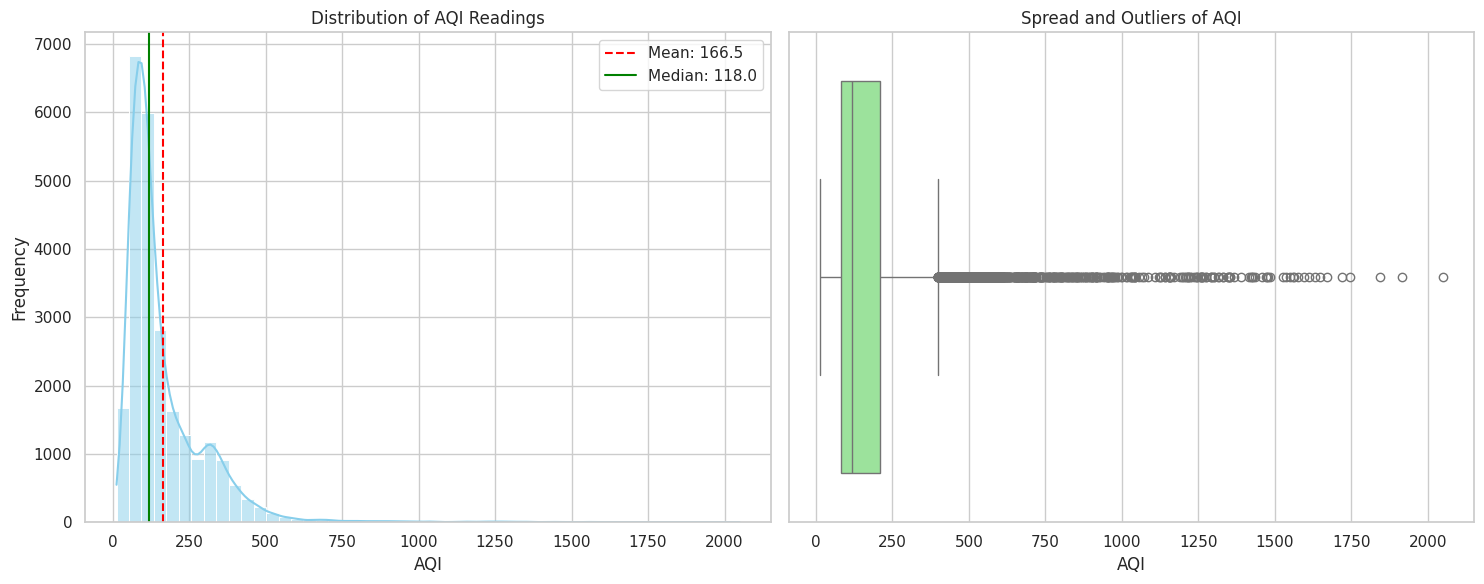

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram
sns.histplot(city_df['AQI'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of AQI Readings')
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Frequency')
axes[0].axvline(city_df['AQI'].mean(), color='red', linestyle='--', label=f"Mean: {city_df['AQI'].mean():.1f}")
axes[0].axvline(city_df['AQI'].median(), color='green', linestyle='-', label=f"Median: {city_df['AQI'].median():.1f}")
axes[0].legend()

# Boxplot
sns.boxplot(x=city_df['AQI'], ax=axes[1], color='lightgreen')
axes[1].set_title('Spread and Outliers of AQI')
axes[1].set_xlabel('AQI')

plt.tight_layout()
plt.show()


Task 5

There are definitely some implausibly high AQI values that look like sensor errors. If we leave them as is, they'll ruin any machine learning model we try to build later. 

Instead of just deleting them completely—which might accidentally delete real smog events—I decided to use the Interquartile Range (IQR) method to find them, and then I capped them at the 99th percentile. This way, we keep the rows and their other valid pollutant readings, but we pull the crazy high AQI numbers down to a more realistic maximum limit.

Number of extreme values detected: 1358
Capping extreme values at: 661.5


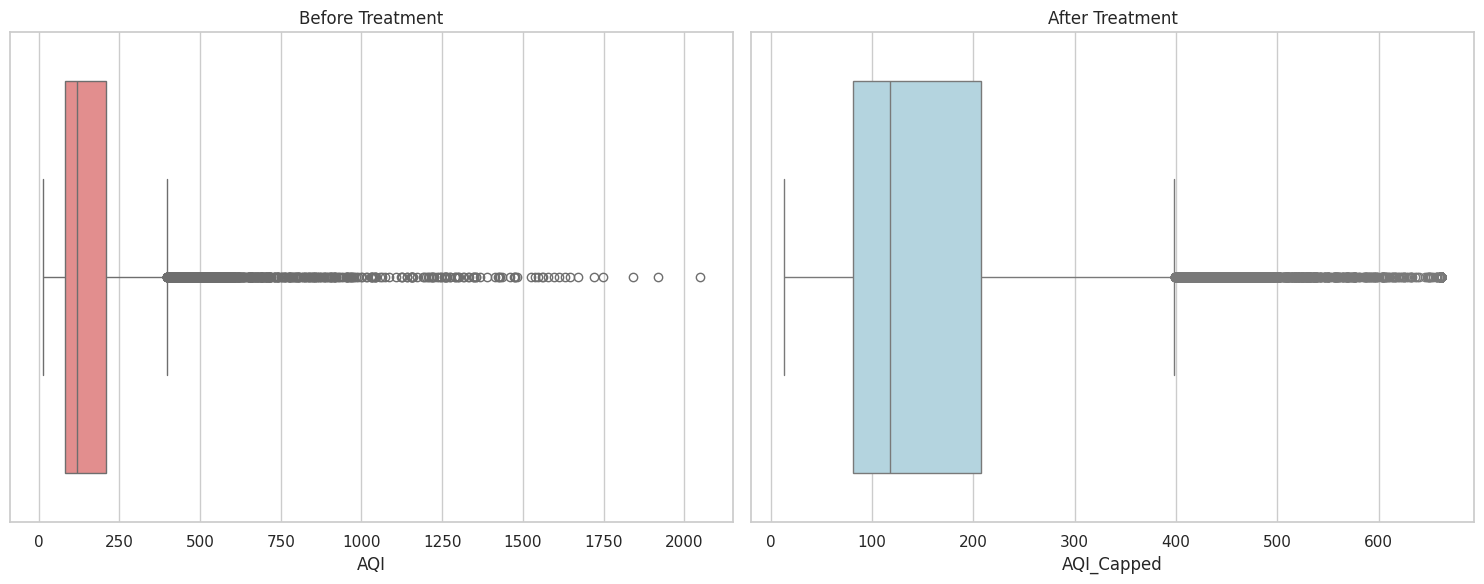

In [33]:
# Identify extremes using IQR
Q1 = city_df['AQI'].quantile(0.25)
Q3 = city_df['AQI'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

extremes_count = (city_df['AQI'] > upper_bound).sum()
print(f"Number of extreme values detected: {extremes_count}")

# Cap at 99th percentile
cap_value = city_df['AQI'].quantile(0.99)
print(f"Capping extreme values at: {cap_value:.1f}")

city_df['AQI_Capped'] = np.where(city_df['AQI'] > cap_value, cap_value, city_df['AQI'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(x=city_df['AQI'], ax=axes[0], color='lightcoral')
axes[0].set_title('Before Treatment')
axes[0].set_xlabel('AQI')

sns.boxplot(x=city_df['AQI_Capped'], ax=axes[1], color='lightblue')
axes[1].set_title('After Treatment')
axes[1].set_xlabel('AQI_Capped')

plt.tight_layout()
plt.show()
